In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
# 시각화 스타일 설정 : 배경 흰색, 파스텔톤

sns.set_style('white')

sns.set_palette('pastel')
# 한글 설정
plt.rcParams["font.family"] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False

In [ ]:
df = pd.read_spss('data/Koweps_hpwc20_2025_beta1.sav')
df

,h20_id,h20_ind,h20_sn,h20_merkey,h_new,h_new1,h20_cobf,p20_wsc,p20_wsl,p20_wgc,...,wc20_63,wc20_64,wc20_5aq4,wc20_5aq5,wc20_5aq6,h20_pers_income1,h20_pers_income2,h20_pers_income3,h20_pers_income4,h20_pers_income5
0,2.0,1.0,1.0,20101.0,0.0,0.0,NaN,0.270248,0.269086,1513.433983,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,3.0,1.0,1.0,30101.0,0.0,0.0,NaN,0.424537,0.400322,2377.476553,...,NaN,NaN,NaN,NaN,NaN,NaN,2423.0,NaN,0.0,NaN
2,4.0,1.0,1.0,40101.0,0.0,0.0,NaN,0.230720,0.216585,1292.070254,...,NaN,NaN,NaN,NaN,NaN,NaN,337.0,NaN,0.0,NaN
3,6.0,1.0,1.0,60101.0,0.0,0.0,NaN,0.541744,0.498132,3033.853323,...,1.0,3.0,2.0,2.0,3.0,2825.0,NaN,NaN,0.0,NaN
4,6.0,1.0,1.0,60101.0,0.0,0.0,NaN,0.852575,0.827786,4774.555169,...,1.0,5.0,1.0,5.0,4.0,NaN,2278.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14910,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,12820.0,NaN,NaN,0.0,NaN
14911,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3149.0,NaN,0.0,NaN
14912,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
14913,12011.0,17.0,1.0,120111701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6600.0,NaN,0.0,NaN


In [52]:
# h20_med8 : 건강검진횟수
# h20_eco9 : 직종
# h20_g4 : 태어난 연도
# h20_med2 : 건강상태

data =df.rename(columns={
    'h20_med8':'health_checkup',
    'h20_eco9':'job_code',
    'h20_g4':'birth',
    'h20_med2':'health'
})
data = data[['health_checkup','health','job_code','birth',]]
data

,health_checkup,health,job_code,birth
0,1.0,4.0,NaN,1945.0
1,1.0,3.0,942.0,1948.0
2,1.0,4.0,NaN,1942.0
3,1.0,3.0,855.0,1962.0
4,0.0,3.0,314.0,1963.0
...,...,...,...,...
14910,1.0,2.0,222.0,1975.0
14911,1.0,2.0,313.0,1976.0
14912,0.0,2.0,NaN,2009.0
14913,1.0,2.0,151.0,1964.0


In [ ]:
# data['health'].unique()  # 고유값 확인 (1:매우불만족 ~5:매우만족)
data['health_checkup'].unique()  # 고유값 확인 


array([1., 0., 2., 9., 4., 3.])

In [54]:
job_name = pd.read_excel('data/(2025년 20차 한국복지패널조사) 조사설계서-가구용(beta1).xlsx',
                            sheet_name = '직종코드(2019 7차 신분류)'
                         )
#소분류 -> job_code, Unnamed: 3 -> job, inplace = True

job_name.rename(columns={
        '소분류' : 'job_code',
        'Unnamed: 3' : 'job'
},inplace= True)

job_name = job_name[['job_code','job']]
job_name

,job_code,job
0,111,의회 의원∙고위 공무원 및 공공단체 임원
1,112,기업 고위 임원
2,121,행정 및 경영 지원 관리자
3,122,마케팅 및 광고∙홍보 관리자
4,131,연구∙교육 및 법률 관련 관리자
...,...,...
151,992,계기∙자판기 및 주차 관리 종사자
152,999,기타 서비스 관련 단순 종사자
153,1001,장교
154,1002,부사관


In [55]:
# data(분석데이터)와 job_name(직업별 매핑표)을 job_code 기준으로 매핑하여 결합 

data= data.merge(job_name, how = 'left', on='job_code')

data

,health_checkup,health,job_code,birth,job
0,1.0,4.0,NaN,1945.0,NaN
1,1.0,3.0,942.0,1948.0,건물 관리원 및 검표원
2,1.0,4.0,NaN,1942.0,NaN
3,1.0,3.0,855.0,1962.0,금속기계 부품 조립원
4,0.0,3.0,314.0,1963.0,비서 및 사무 보조원
...,...,...,...,...,...
14910,1.0,2.0,222.0,1975.0,컴퓨터 시스템 및 소프트웨어 전문가
14911,1.0,2.0,313.0,1976.0,회계 및 경리 사무원
14912,0.0,2.0,NaN,2009.0,NaN
14913,1.0,2.0,151.0,1964.0,판매 및 운송 관리자


In [56]:
data.isnull().sum()
data = data.dropna(subset='job')
data

,health_checkup,health,job_code,birth,job
1,1.0,3.0,942.0,1948.0,건물 관리원 및 검표원
3,1.0,3.0,855.0,1962.0,금속기계 부품 조립원
4,0.0,3.0,314.0,1963.0,비서 및 사무 보조원
7,1.0,3.0,941.0,1940.0,청소원 및 환경미화원
8,1.0,4.0,151.0,1970.0,판매 및 운송 관리자
...,...,...,...,...,...
14906,1.0,2.0,151.0,1976.0,판매 및 운송 관리자
14907,0.0,2.0,312.0,1977.0,경영 관련 사무원
14910,1.0,2.0,222.0,1975.0,컴퓨터 시스템 및 소프트웨어 전문가
14911,1.0,2.0,313.0,1976.0,회계 및 경리 사무원


In [57]:
# age 컬럼생성 = 2026 - 출생연도

data['age'] = 2026 - data['birth']
# 나이를 정수형으로
data['age'] = data['age'].astype(int)
data

,health_checkup,health,job_code,birth,job,age
1,1.0,3.0,942.0,1948.0,건물 관리원 및 검표원,78
3,1.0,3.0,855.0,1962.0,금속기계 부품 조립원,64
4,0.0,3.0,314.0,1963.0,비서 및 사무 보조원,63
7,1.0,3.0,941.0,1940.0,청소원 및 환경미화원,86
8,1.0,4.0,151.0,1970.0,판매 및 운송 관리자,56
...,...,...,...,...,...,...
14906,1.0,2.0,151.0,1976.0,판매 및 운송 관리자,50
14907,0.0,2.0,312.0,1977.0,경영 관련 사무원,49
14910,1.0,2.0,222.0,1975.0,컴퓨터 시스템 및 소프트웨어 전문가,51
14911,1.0,2.0,313.0,1976.0,회계 및 경리 사무원,50


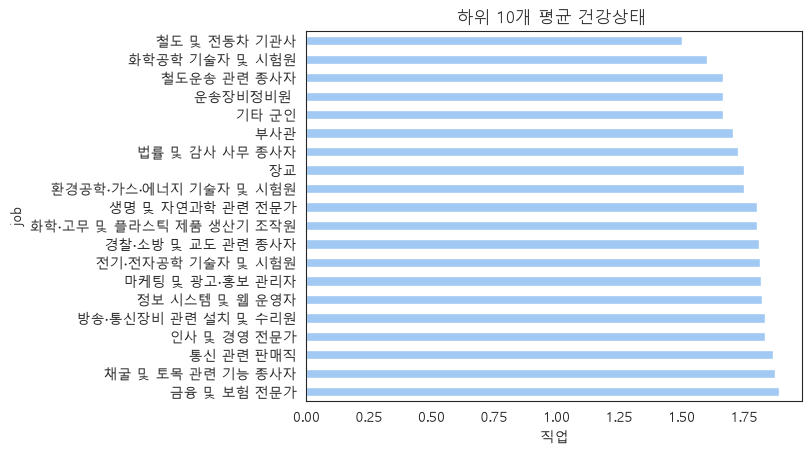

In [80]:
data_check = data.groupby('job')['health'].mean()
data_check = data_check.sort_values(ascending=False).tail(20)
plt.Figure(figsize= (8,6))
data_check.plot(kind='barh')
plt.title("하위 10개 평균 건강상태 ")
plt.xlabel("직업")
plt.show()

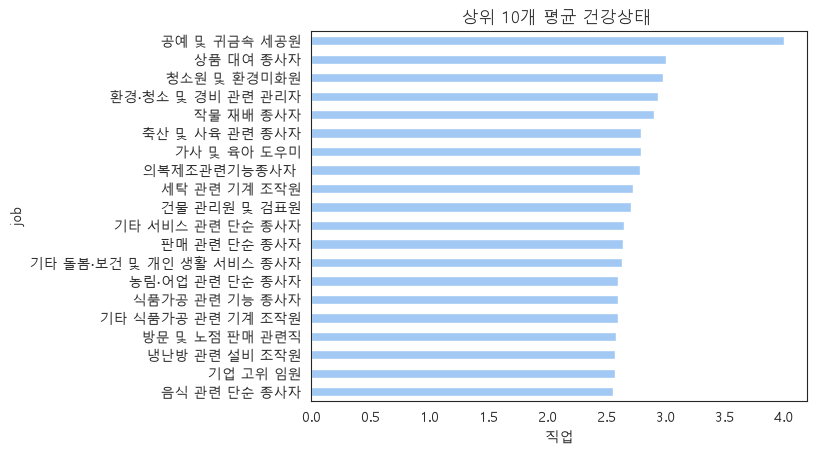

In [81]:
data_check = data.groupby('job')['health'].mean()
data_check = data_check.sort_values(ascending=False).head(20).sort_values()
plt.Figure(figsize= (8,6))
data_check.plot(kind='barh')
plt.title("상위 10개 평균 건강상태 ")
plt.xlabel("직업")
plt.show()

In [82]:
data = data.assign(
    agetype = np.where(
        data['age'] < 30,'youth',   # 데이터 나이 30 미만 청년층
        np.where(
            data['age'] <60 ,'middle age','senior'  # 30~59 중장년층,60세 이상은 고령층
        )
    )
)
data

,health_checkup,health,job_code,birth,job,age,agetype
1,1.0,3.0,942.0,1948.0,건물 관리원 및 검표원,78,senior
3,1.0,3.0,855.0,1962.0,금속기계 부품 조립원,64,senior
4,0.0,3.0,314.0,1963.0,비서 및 사무 보조원,63,senior
7,1.0,3.0,941.0,1940.0,청소원 및 환경미화원,86,senior
8,1.0,4.0,151.0,1970.0,판매 및 운송 관리자,56,middle age
...,...,...,...,...,...,...,...
14906,1.0,2.0,151.0,1976.0,판매 및 운송 관리자,50,middle age
14907,0.0,2.0,312.0,1977.0,경영 관련 사무원,49,middle age
14910,1.0,2.0,222.0,1975.0,컴퓨터 시스템 및 소프트웨어 전문가,51,middle age
14911,1.0,2.0,313.0,1976.0,회계 및 경리 사무원,50,middle age


agetype
middle age    2.147051
senior        2.791937
youth         1.887776
Name: health, dtype: float64

In [87]:
df = pd.read_csv('data/music_streaming_habits_2026.csv')
df

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False


In [90]:
df['country'].unique()

<StringArray>
['Australia',   'Germany',     'Japan',     'India',   'Nigeria',    'Canada',
       'USA',        'UK',    'Brazil',    'France']
Length: 10, dtype: str

In [92]:
df.groupby('age')['daily_listening_minutes'].mean()

age
13    135.599119
14    130.797101
15    159.585714
16    139.680556
17    122.554455
18    138.333333
19    138.301205
20    147.561151
21    123.089431
22    139.704545
23    139.390071
24    152.679245
25    142.304813
26    131.092391
27    143.550239
28    149.232143
29    133.189474
30    145.366864
31    145.719178
32    143.178571
33    151.055556
34    123.522581
35    148.532710
36    123.108333
37    125.772727
38    124.097826
39    132.085366
40    138.535211
41    134.342857
42    152.300000
43    128.903846
44    136.780488
45    140.523810
46    123.739130
47    165.000000
48    162.928571
49    165.454545
50    197.375000
51    107.250000
52    147.500000
53    127.800000
55    276.500000
56     61.000000
57     73.666667
Name: daily_listening_minutes, dtype: float64

In [97]:
df = df.assign(
    agetype = np.where(
        df['age'] < 25,'student',   # 데이터 나이 30 미만 청년층
        np.where(
            df['age'] <40 ,'youth',
            np.where(df['age']<60,'middle','senior') 
        )
    )
)
df

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too,agetype
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True,student
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True,student
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True,youth
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False,youth
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True,student
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False,youth
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True,youth
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True,middle
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False,youth


In [ ]:
country=df.groupby('country')['platform']
country

TypeError: dtype 'str' does not support operation 'mean'

<Axes: xlabel='platform', ylabel='count'>

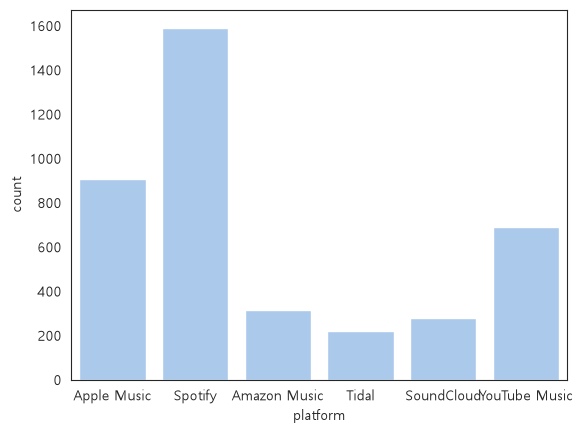

In [123]:
sns.countplot(x = 'platform',data = df)

In [124]:
df

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too,agetype
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True,student
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True,student
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True,youth
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False,youth
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True,student
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False,youth
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True,youth
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True,middle
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False,youth


Text(0.5, 1.0, '나이별 음악 스트리밍 시간')

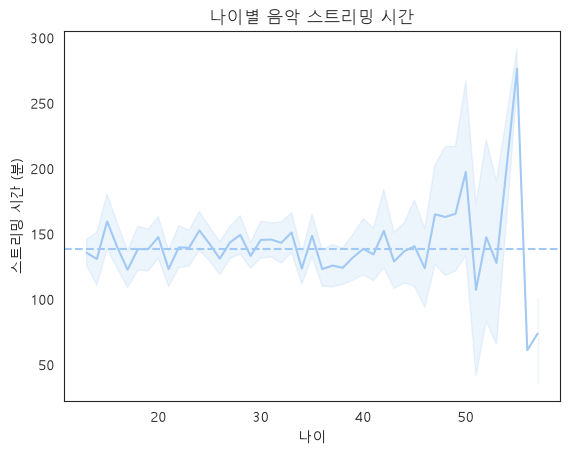

In [145]:
# 나이별 음악 스트리밍 선그래프 시각화

sns.lineplot(x = 'age', y = 'daily_listening_minutes',data = df)
plt.axhline(df['daily_listening_minutes'].mean(),linestyle = '--')
plt.xlabel("나이")
plt.ylabel("스트리밍 시간 (분)")
plt.title('나이별 음악 스트리밍 시간')

In [133]:
df

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too,agetype
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True,student
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True,student
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True,youth
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False,youth
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True,student
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False,youth
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True,youth
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True,middle
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False,youth


Text(0.5, 1.0, '나이별 음악장르 선호도')

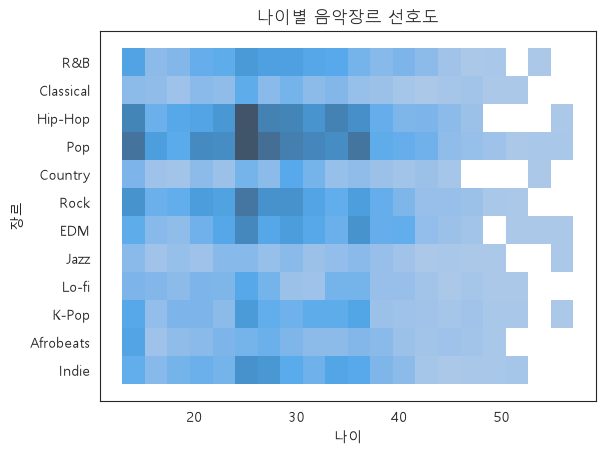

In [ ]:
# 나이별 음악장르 시각화
sns.histplot(x = 'age', 
             y = 'top_genre',
             data = df)
plt.xlabel("나이")
plt.ylabel("장르")
plt.title('나이별 음악장르 선호도')

In [152]:
df

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too,agetype
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True,student
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True,student
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True,youth
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False,youth
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True,student
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False,youth
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True,youth
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True,middle
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False,youth


AttributeError: 'Series' object has no attribute 'barplot'

In [168]:
df.sort_index()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too,agetype
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True,student
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True,student
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True,youth
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False,youth
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True,student
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False,youth
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True,youth
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True,middle
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False,youth


In [173]:
song_data = df.groupby('country')['platform']

sns.countplot(song)

NameError: name 'song' is not defined